# Interval Scheduling Maximisation — Weighted Intervals (Greedy)

In [1]:
class Job:
    def __init__(self, name, start, end, profit):
        self.name = name
        self.start = start
        self.end = end
        self.profit = profit

    def __repr__(self):
        return f"Job({self.name}, [{self.start},{self.end}], profit={self.profit})"


def greedy_earliest_finish_time(jobs):
    """
    Classic activity-selection greedy: always pick the next job with the
    earliest finish time among those compatible with what's already chosen.
    This MAXIMISES COUNT of non-overlapping jobs, but ignores profit/weight.
    """
    jobs_sorted = sorted(jobs, key=lambda j: j.end)
    selected = []
    last_end = float('-inf')

    for job in jobs_sorted:
        if job.start >= last_end:
            selected.append(job)
            last_end = job.end

    total_profit = sum(j.profit for j in selected)
    return total_profit, selected


def greedy_highest_profit_first(jobs):
    """
    Alternative greedy: always pick the next-highest-profit job that doesn't
    conflict with what's already selected. Also NOT guaranteed optimal —
    included to show that no simple greedy rule reliably solves the
    weighted version (motivating why DP from the previous notebook is needed).
    """
    jobs_sorted = sorted(jobs, key=lambda j: j.profit, reverse=True)
    selected = []

    def conflicts(job, chosen):
        return any(not (job.end <= c.start or job.start >= c.end) for c in chosen)

    for job in jobs_sorted:
        if not conflicts(job, selected):
            selected.append(job)

    total_profit = sum(j.profit for j in selected)
    return total_profit, sorted(selected, key=lambda j: j.start)

## Comparing Greedy Strategies Against the Optimal (DP) Solution

In [2]:
import sys
sys.path.append('.')

# Re-include the DP function here so this notebook is self-contained
import bisect

def weighted_job_scheduling(jobs):
    if not jobs:
        return 0, []
    jobs_sorted = sorted(jobs, key=lambda j: j.end)
    n = len(jobs_sorted)
    end_times = [j.end for j in jobs_sorted]

    def latest_non_conflicting(i):
        idx = bisect.bisect_right(end_times, jobs_sorted[i].start, 0, i) - 1
        return idx

    dp = [0] * (n + 1)
    choice = [False] * (n + 1)
    for i in range(1, n + 1):
        job = jobs_sorted[i - 1]
        p = latest_non_conflicting(i - 1)
        include_profit = job.profit + (dp[p + 1] if p != -1 else 0)
        exclude_profit = dp[i - 1]
        if include_profit > exclude_profit:
            dp[i] = include_profit
            choice[i] = True
        else:
            dp[i] = exclude_profit
            choice[i] = False

    selected = []
    i = n
    while i > 0:
        if choice[i]:
            job = jobs_sorted[i - 1]
            selected.append(job)
            p = latest_non_conflicting(i - 1)
            i = p + 1
        else:
            i -= 1
    selected.reverse()
    return dp[n], selected


# The same "single high-value job beats several small ones" case from the DP notebook
jobs = [
    Job("A", 1, 3, 50),
    Job("B", 3, 5, 20),
    Job("C", 6, 19, 100),
    Job("D", 2, 100, 200),
]

optimal_profit, optimal_selection = weighted_job_scheduling(jobs)
efst_profit, efst_selection = greedy_earliest_finish_time(jobs)
hpf_profit, hpf_selection = greedy_highest_profit_first(jobs)

print("=== Optimal (DP) ===")
print(f"Profit: {optimal_profit}, Jobs: {[j.name for j in optimal_selection]}")

print("\n=== Greedy: Earliest Finish Time ===")
print(f"Profit: {efst_profit}, Jobs: {[j.name for j in efst_selection]}")
print(f"Optimal? {efst_profit == optimal_profit}")

print("\n=== Greedy: Highest Profit First ===")
print(f"Profit: {hpf_profit}, Jobs: {[j.name for j in hpf_selection]}")
print(f"Optimal? {hpf_profit == optimal_profit}")

=== Optimal (DP) ===
Profit: 200, Jobs: ['D']

=== Greedy: Earliest Finish Time ===
Profit: 170, Jobs: ['A', 'B', 'C']
Optimal? False

=== Greedy: Highest Profit First ===
Profit: 200, Jobs: ['D']
Optimal? True


## Case Where "Highest Profit First" Greedy Also Fails

In [3]:
# A case designed to break Highest-Profit-First: one big job blocks two
# medium jobs whose combined profit is higher.
jobs2 = [
    Job("X", 1, 5, 60),    # highest single profit, but blocks Y and Z
    Job("Y", 1, 3, 35),
    Job("Z", 3, 5, 35),
]

optimal_profit2, optimal_selection2 = weighted_job_scheduling(jobs2)
efst_profit2, efst_selection2 = greedy_earliest_finish_time(jobs2)
hpf_profit2, hpf_selection2 = greedy_highest_profit_first(jobs2)

print("=== Optimal (DP) ===")
print(f"Profit: {optimal_profit2}, Jobs: {[j.name for j in optimal_selection2]}")

print("\n=== Greedy: Earliest Finish Time ===")
print(f"Profit: {efst_profit2}, Jobs: {[j.name for j in efst_selection2]}")
print(f"Optimal? {efst_profit2 == optimal_profit2}")

print("\n=== Greedy: Highest Profit First ===")
print(f"Profit: {hpf_profit2}, Jobs: {[j.name for j in hpf_selection2]}")
print(f"Optimal? {hpf_profit2 == optimal_profit2}")

print("\nExpected: DP picks Y+Z (35+35=70), beating X alone (60).")
print("Highest-Profit-First greedily locks in X first (since it has the single highest profit),")
print("which then blocks both Y and Z — proving this greedy rule is also not optimal.")

=== Optimal (DP) ===
Profit: 70, Jobs: ['Y', 'Z']

=== Greedy: Earliest Finish Time ===
Profit: 70, Jobs: ['Y', 'Z']
Optimal? True

=== Greedy: Highest Profit First ===
Profit: 60, Jobs: ['X']
Optimal? False

Expected: DP picks Y+Z (35+35=70), beating X alone (60).
Highest-Profit-First greedily locks in X first (since it has the single highest profit),
which then blocks both Y and Z — proving this greedy rule is also not optimal.


## Visualizing Greedy vs Optimal

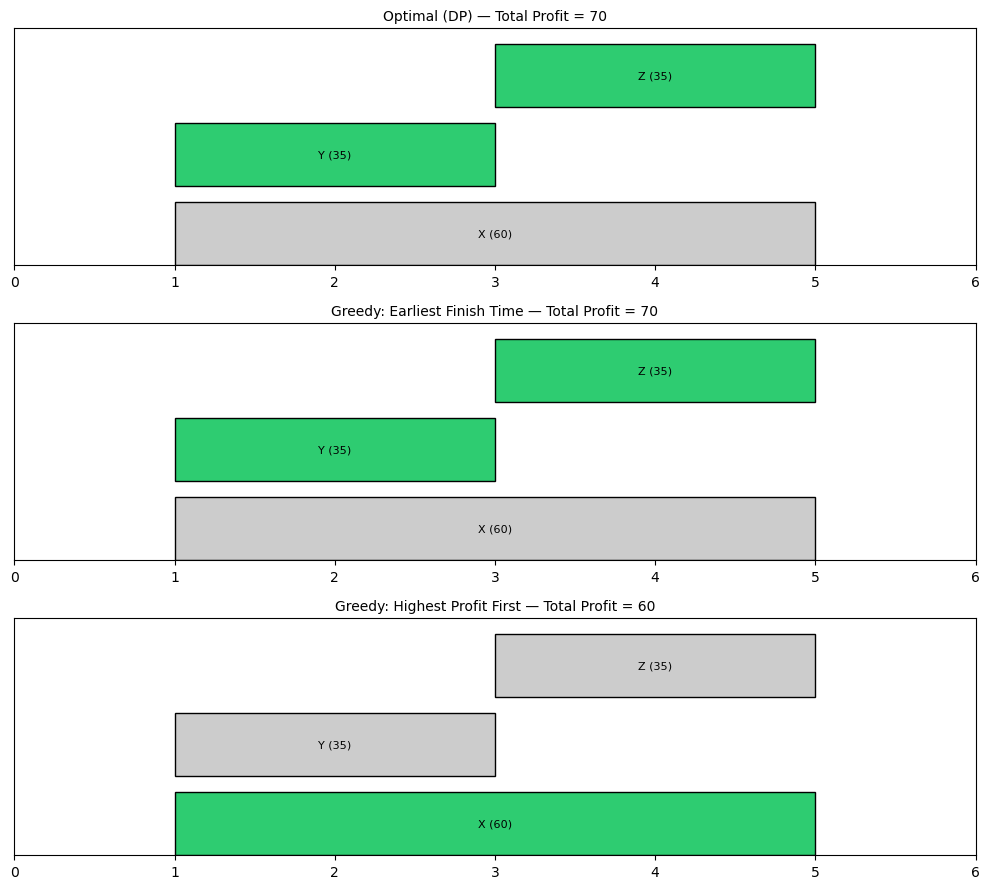

In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def visualize_comparison(jobs, solutions, titles):
    fig, axes = plt.subplots(len(solutions), 1, figsize=(10, 3 * len(solutions)))
    if len(solutions) == 1:
        axes = [axes]

    jobs_sorted = sorted(jobs, key=lambda j: j.start)
    max_end = max(j.end for j in jobs)

    for ax, selected, title in zip(axes, solutions, titles):
        selected_names = {j.name for j in selected}
        for row, job in enumerate(jobs_sorted):
            color = '#2ecc71' if job.name in selected_names else '#cccccc'
            ax.add_patch(mpatches.Rectangle((job.start, row), job.end - job.start, 0.8,
                                              facecolor=color, edgecolor='black'))
            ax.text(job.start + (job.end - job.start) / 2, row + 0.4,
                     f"{job.name} ({job.profit})", ha='center', va='center', fontsize=8)
        ax.set_xlim(0, max_end + 1)
        ax.set_ylim(0, len(jobs))
        ax.set_yticks([])
        total = sum(j.profit for j in selected)
        ax.set_title(f"{title} — Total Profit = {total}", fontsize=10)

    plt.tight_layout()
    plt.show()

visualize_comparison(
    jobs2,
    [optimal_selection2, efst_selection2, hpf_selection2],
    ["Optimal (DP)", "Greedy: Earliest Finish Time", "Greedy: Highest Profit First"]
)